# Model 1: Basic Seq2Seq (LSTM, no attention)

**Prerequisites:** run `01_preprocessing.ipynb` first to generate the processed data files.

**Environments:** runs locally and in Google Colab. In Colab, use a GPU runtime (Runtime > Change runtime type > T4 GPU) and run `01_preprocessing.ipynb` in the same session beforehand.

In [1]:
import json
import sys
from pathlib import Path

import pandas as pd
import torch
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader, Dataset

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    PROCESSED_DIR = Path("processed_full")
    CHECKPOINT_PATH = Path("best_basic_full.pt")
else:
    PROCESSED_DIR = Path("../../data/processed_full")
    CHECKPOINT_PATH = Path("../../results/best_basic_full.pt")

CHECKPOINT_PATH.parent.mkdir(exist_ok=True)

PAD_IDX, SOS_IDX, EOS_IDX, UNK_IDX = 0, 1, 2, 3
# Keskar et al. (2017): small batches converge to flat minima, improving
# generalisation; large batches converge to sharp minima with poorer
# generalisation.
BATCH_SIZE = 32

with open(PROCESSED_DIR / "token2idx.json") as f:
    tokenToIdx = json.load(f)
idxToToken = {v: k for k, v in tokenToIdx.items()}


def encode(tokens: list[str]) -> list[int]:
    """
    Converts a list of string tokens to an integer ID sequence with SOS/EOS.
    @param tokens: List of string tokens to encode.
    @return: List of integer token IDs with SOS at index 0 and EOS at the end.
    """
    return [SOS_IDX] + [tokenToIdx.get(t, UNK_IDX) for t in tokens] + [EOS_IDX]


def decode(ids: list[int]) -> list[str]:
    """
    Converts integer token IDs back to string tokens, skipping special tokens.
    @param ids: List of integer token IDs.
    @return: List of string tokens with PAD, SOS, and EOS removed.
    """
    return [idxToToken[i] for i in ids if i not in {PAD_IDX, SOS_IDX, EOS_IDX}]


with open(PROCESSED_DIR / "train.json") as f:
    trainDf = pd.DataFrame(json.load(f))
with open(PROCESSED_DIR / "dev.json") as f:
    devDf = pd.DataFrame(json.load(f))
with open(PROCESSED_DIR / "test.json") as f:
    testDf = pd.DataFrame(json.load(f))

print(f"Vocabulary size : {len(tokenToIdx):,}")
print(
    f"Q&A pairs -- train: {len(trainDf):,}  dev: {len(devDf):,}  test: {len(testDf):,}"
)


class WikiQADataset(Dataset):
    """
    PyTorch Dataset wrapping the pre-encoded WikiQA question-answer pairs.
    @param dataFrame: DataFrame with 'q_ids' and 'a_ids' columns of integer ID lists.
    """

    def __init__(self, dataFrame: pd.DataFrame):
        self.qIds = dataFrame["q_ids"].tolist()
        self.aIds = dataFrame["a_ids"].tolist()

    def __len__(self) -> int:
        return len(self.qIds)

    def __getitem__(self, idx: int):
        return torch.tensor(self.qIds[idx]), torch.tensor(self.aIds[idx])


def collateBatch(batch: list) -> dict:
    """
    Pads a list of (question, answer) tensor pairs into fixed-length batch tensors.
    @param batch: List of (question tensor, answer tensor) pairs from WikiQADataset.
    @return: Dict with keys 'src', 'tgt', and 'srcLens' as batch tensors.
    """
    questions, answers = zip(*batch)
    src = pad_sequence(questions, batch_first=True, padding_value=PAD_IDX)
    tgt = pad_sequence(answers, batch_first=True, padding_value=PAD_IDX)
    return {
        "src": src,
        "tgt": tgt,
        "srcLens": torch.tensor([len(q) for q in questions]),
    }


trainLoader = DataLoader(
    WikiQADataset(trainDf), batch_size=BATCH_SIZE, shuffle=True, collate_fn=collateBatch
)
devLoader = DataLoader(
    WikiQADataset(devDf), batch_size=BATCH_SIZE, shuffle=False, collate_fn=collateBatch
)
testLoader = DataLoader(
    WikiQADataset(testDf), batch_size=BATCH_SIZE, shuffle=False, collate_fn=collateBatch
)

print(
    f"Batches -- train: {len(trainLoader)}  dev: {len(devLoader)}  test: {len(testLoader)}"
)

Vocabulary size : 17,956
Q&A pairs -- train: 16,206  dev: 2,194  test: 4,934
Batches -- train: 507  dev: 69  test: 155


---

## Part 2: Model architecture

A standard LSTM encoder-decoder with no attention.

The encoder reads the full question and compresses it into a hidden state `(h_n, c_n)`. The decoder is stepped one token at a time, initialised with that hidden state. During training, teacher forcing randomly replaces the decoder's own previous prediction with the ground-truth token.

In [2]:
import torch.nn as nn

# -- Hyperparameters ----------------------------------------------------------
# Sutskever et al. (2014): 1000-dim embeddings matched to 1000-dim hidden units;
# equal embedding and hidden dimensions is the standard convention in basic
# encoder-decoder implementations.
EMBED_DIM = 128
# With the full-vocabulary dataset (~18k tokens) and ~2000 training pairs the
# model is severely over-parameterised at 256 hidden units (~14.9M parameters).
# Reducing to 128 brings total parameters to ~7.4M, narrowing the
# bias-variance gap. Geman et al. (1992), Neural Computation.
HIDDEN_DIM = 128
# Sutskever et al. (2014) use 4 layers on 12M+ WMT sentence pairs and report
# ~10% perplexity reduction per additional layer. On the present dataset, a
# single layer is preferred to minimise overfitting.
N_LAYERS = 1
# Srivastava et al. (2014): 'p can simply be set at 0.5, which seems to be
# close to optimal for a wide range of networks and tasks'.
DROPOUT = 0.5

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


In [3]:
class Encoder(nn.Module):
    """
    LSTM encoder that compresses an input token sequence into a hidden state.
    @param vocabSize: Number of tokens in the vocabulary.
    @param embedDim: Dimensionality of the token embedding vectors.
    @param hiddenDim: Number of hidden units in the LSTM.
    @param nLayers: Number of stacked LSTM layers.
    @param dropout: Dropout probability applied to embeddings and between LSTM layers.
    """

    def __init__(
        self,
        vocabSize: int,
        embedDim: int,
        hiddenDim: int,
        nLayers: int,
        dropout: float,
    ):
        super().__init__()
        self.embedding = nn.Embedding(vocabSize, embedDim, padding_idx=PAD_IDX)
        self.lstm = nn.LSTM(
            embedDim,
            hiddenDim,
            nLayers,
            batch_first=True,
            dropout=dropout if nLayers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, src: torch.Tensor, srcLens: torch.Tensor):
        embedded = self.dropout(self.embedding(src))
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded, srcLens.cpu(), batch_first=True, enforce_sorted=False
        )
        _, hidden = self.lstm(packed)
        return hidden


class Decoder(nn.Module):
    """
    LSTM decoder that generates one output token per step given a hidden state.
    @param vocabSize: Number of tokens in the vocabulary.
    @param embedDim: Dimensionality of the token embedding vectors.
    @param hiddenDim: Number of hidden units in the LSTM.
    @param nLayers: Number of stacked LSTM layers.
    @param dropout: Dropout probability applied to embeddings.
    """

    def __init__(
        self,
        vocabSize: int,
        embedDim: int,
        hiddenDim: int,
        nLayers: int,
        dropout: float,
    ):
        super().__init__()
        self.embedding = nn.Embedding(vocabSize, embedDim, padding_idx=PAD_IDX)
        self.lstm = nn.LSTM(
            embedDim,
            hiddenDim,
            nLayers,
            batch_first=True,
            dropout=dropout if nLayers > 1 else 0.0,
        )
        self.fc = nn.Linear(hiddenDim, vocabSize)
        self.dropout = nn.Dropout(dropout)

    def forward(self, token: torch.Tensor, hidden):
        embedded = self.dropout(self.embedding(token.unsqueeze(1)))
        output, hidden = self.lstm(embedded, hidden)
        logits = self.fc(output.squeeze(1))
        return logits, hidden


class Seq2Seq(nn.Module):
    """
    Full encoder-decoder sequence-to-sequence model combining Encoder and Decoder.
    @param encoder: Encoder instance that produces hidden states from source sequences.
    @param decoder: Decoder instance that generates tokens step-by-step.
    """

    def __init__(self, encoder: Encoder, decoder: Decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(
        self,
        src: torch.Tensor,
        srcLens: torch.Tensor,
        tgt: torch.Tensor,
        teacherForcingRatio: float = 0.5,
    ):
        batchSize, tgtLen = tgt.shape
        vocabSize = self.decoder.fc.out_features

        hidden = self.encoder(src, srcLens)

        outputs = torch.zeros(batchSize, tgtLen, vocabSize, device=src.device)
        token = tgt[:, 0]  # <sos>

        for t in range(1, tgtLen):
            logits, hidden = self.decoder(token, hidden)
            outputs[:, t] = logits
            useTeacher = torch.rand(1).item() < teacherForcingRatio
            token = tgt[:, t] if useTeacher else logits.argmax(dim=-1)

        return outputs

In [4]:
encoder = Encoder(len(tokenToIdx), EMBED_DIM, HIDDEN_DIM, N_LAYERS, DROPOUT)
decoder = Decoder(len(tokenToIdx), EMBED_DIM, HIDDEN_DIM, N_LAYERS, DROPOUT)
model = Seq2Seq(encoder, decoder).to(DEVICE)

nParams = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {nParams:,}")

# Smoke test -- one forward pass
batch = next(iter(trainLoader))
out = model(batch["src"].to(DEVICE), batch["srcLens"], batch["tgt"].to(DEVICE))
print(
    f"Output shape: {out.shape}  (expected [batch={BATCH_SIZE}, tgt_len, vocab={len(tokenToIdx)}])"
)

Trainable parameters: 7,177,252
Output shape: torch.Size([32, 32, 17956])  (expected [batch=32, tgt_len, vocab=17956])


---

## Part 3: Training

- **Loss:** cross-entropy, `<pad>` positions ignored
- **Optimiser:** Adam
- **Gradient clipping:** norm clipped to 1.0 to prevent exploding gradients (common with LSTMs)
- **Checkpoint:** best model by validation loss is saved to `CHECKPOINT_PATH`

In [5]:
import math
import time
import matplotlib.pyplot as plt

# Extended ceiling; early stopping will terminate before this if
# validation loss stops improving.
EPOCHS = 50
# Kingma and Ba (2015): default alpha=0.001; halved for small-dataset stability.
LEARNING_RATE = 5e-4
# Pascanu, Mikolov and Bengio (2013): norm clipping prevents exploding
# gradients in RNNs; threshold is insensitive over a wide range.
CLIP = 1.0
# Williams and Zipser (1989): teacher forcing feeds ground-truth tokens as
# decoder input, stabilising early training by preventing compounding decoder
# errors. A fixed ratio of 0.7 is a common starting point. Bengio et al.
# (2015) propose scheduled sampling to gradually reduce this ratio during
# training to close the exposure-bias gap between training and inference.
TEACHER_FORCING = 0.7
# Increased from 3 to 5: with ~66 training batches per epoch, patience=3
# halts after very little loss landscape exploration. Five epochs gives the
# optimiser more room before stopping.
PATIENCE = 5

# Szegedy et al. (2016): label smoothing (eps=0.1) penalises overconfident
# predictions. With a vocabulary of ~18k tokens, the model can collapse to
# high-frequency stopwords; smoothing directly counteracts this.
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX, label_smoothing=0.1)
# Krogh and Hertz (1992): L2 weight decay (weight_decay=1e-4) penalises
# large weights and complements dropout as a second regulariser.
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
# Smith (2018): reducing the learning rate on validation plateau allows the
# optimiser to refine rather than continue overshooting on a stagnant loss
# landscape. Factor 0.5, patience 2 epochs, minimum lr 1e-5.
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=2, min_lr=1e-5
)


def trainEpoch(
    model: Seq2Seq,
    loader: DataLoader,
    optimizer,
    criterion,
    clip: float,
) -> float:
    """
    Runs one full training pass over the provided data loader.
    @param model: The Seq2Seq model to train.
    @param loader: DataLoader yielding batches with 'src', 'tgt', and 'srcLens' keys.
    @param optimizer: Optimizer instance for parameter updates.
    @param criterion: Loss function (CrossEntropyLoss with PAD ignored).
    @param clip: Maximum gradient norm for gradient clipping.
    @return: Mean cross-entropy loss over all batches.
    """
    model.train()
    totalLoss = 0.0
    for batch in loader:
        src = batch["src"].to(DEVICE)
        tgt = batch["tgt"].to(DEVICE)
        srcLens = batch["srcLens"]

        optimizer.zero_grad()
        output = model(src, srcLens, tgt, TEACHER_FORCING)

        loss = criterion(
            output[:, 1:].reshape(-1, output.size(-1)), tgt[:, 1:].reshape(-1)
        )
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        totalLoss += loss.item()
    return totalLoss / len(loader)


@torch.no_grad()
def evaluate(model: Seq2Seq, loader: DataLoader, criterion) -> float:
    """
    Evaluates the model on a data loader without updating parameters.
    @param model: The Seq2Seq model to evaluate.
    @param loader: DataLoader yielding batches with 'src', 'tgt', and 'srcLens' keys.
    @param criterion: Loss function (CrossEntropyLoss with PAD ignored).
    @return: Mean cross-entropy loss over all batches.
    """
    model.eval()
    totalLoss = 0.0
    for batch in loader:
        src = batch["src"].to(DEVICE)
        tgt = batch["tgt"].to(DEVICE)
        srcLens = batch["srcLens"]
        output = model(src, srcLens, tgt, teacherForcingRatio=0.0)
        totalLoss += criterion(
            output[:, 1:].reshape(-1, output.size(-1)), tgt[:, 1:].reshape(-1)
        ).item()
    return totalLoss / len(loader)

In [6]:
trainLosses, valLosses = [], []
bestValLoss = float("inf")
epochsNoImprove = 0

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    trainLoss = trainEpoch(model, trainLoader, optimizer, criterion, CLIP)
    valLoss = evaluate(model, devLoader, criterion)
    scheduler.step(valLoss)
    elapsed = time.time() - t0

    trainLosses.append(trainLoss)
    valLosses.append(valLoss)

    marker = ""
    if valLoss < bestValLoss:
        bestValLoss = valLoss
        epochsNoImprove = 0
        torch.save(
            {
                "model_state": model.state_dict(),
                "tokenToIdx": tokenToIdx,
                "embed_dim": EMBED_DIM,
                "hidden_dim": HIDDEN_DIM,
                "n_layers": N_LAYERS,
                "dropout": DROPOUT,
            },
            CHECKPOINT_PATH,
        )
        marker = "  ✓ saved"
    else:
        epochsNoImprove += 1
        if epochsNoImprove >= PATIENCE:
            print(
                f"Early stopping at epoch {epoch}  (no improvement for {PATIENCE} epochs)"
            )
            break

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train loss {trainLoss:.4f} (ppl {math.exp(trainLoss):6.2f}) | "
        f"val loss {valLoss:.4f} (ppl {math.exp(valLoss):6.2f}) | "
        f"{elapsed:.1f}s{marker}"
    )

print(f"\nBest val loss: {bestValLoss:.4f}")

Epoch 01/50 | train loss 7.6176 (ppl 2033.64) | val loss 7.3962 (ppl 1629.77) | 33.6s  ✓ saved
Epoch 02/50 | train loss 7.2956 (ppl 1473.80) | val loss 7.3952 (ppl 1628.23) | 31.8s  ✓ saved
Epoch 03/50 | train loss 7.2476 (ppl 1404.75) | val loss 7.3846 (ppl 1610.91) | 34.2s  ✓ saved
Epoch 04/50 | train loss 7.2108 (ppl 1353.92) | val loss 7.3849 (ppl 1611.41) | 31.5s
Epoch 05/50 | train loss 7.1712 (ppl 1301.46) | val loss 7.3974 (ppl 1631.71) | 31.4s
Epoch 06/50 | train loss 7.1349 (ppl 1254.96) | val loss 7.3991 (ppl 1634.49) | 31.5s
Epoch 07/50 | train loss 7.0935 (ppl 1204.12) | val loss 7.3904 (ppl 1620.42) | 31.4s
Early stopping at epoch 8  (no improvement for 5 epochs)

Best val loss: 7.3846


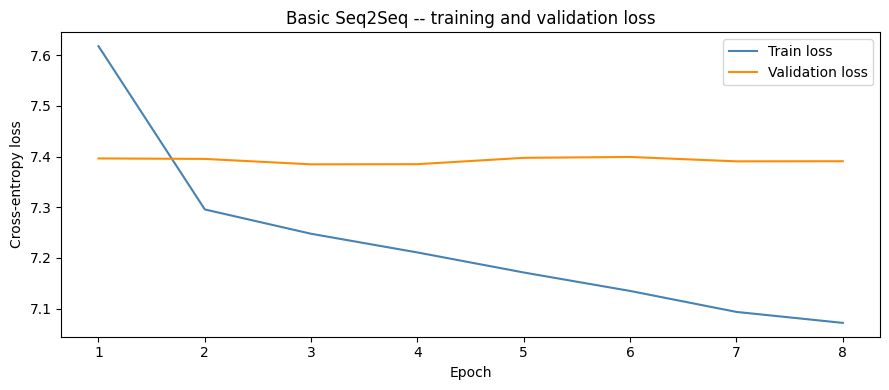

In [7]:
epochsRange = range(1, len(trainLosses) + 1)

plt.figure(figsize=(9, 4))
plt.plot(epochsRange, trainLosses, label="Train loss", color="steelblue")
plt.plot(epochsRange, valLosses, label="Validation loss", color="darkorange")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("Basic Seq2Seq -- training and validation loss")
plt.legend()
plt.tight_layout()
plt.savefig(CHECKPOINT_PATH.parent / "basic_loss_curves.png", dpi=150)
plt.show()

---

## Part 5: Inference

Load the best checkpoint and generate answers greedily (no teacher forcing).

In [8]:
import re
import nltk

nltk.download("punkt_tab", quiet=True)

checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)

ckptTokenToIdx = checkpoint["tokenToIdx"]
ckptEncoder = Encoder(
    len(ckptTokenToIdx),
    checkpoint["embed_dim"],
    checkpoint["hidden_dim"],
    checkpoint["n_layers"],
    checkpoint["dropout"],
)
ckptDecoder = Decoder(
    len(ckptTokenToIdx),
    checkpoint["embed_dim"],
    checkpoint["hidden_dim"],
    checkpoint["n_layers"],
    checkpoint["dropout"],
)
bestModel = Seq2Seq(ckptEncoder, ckptDecoder).to(DEVICE)
bestModel.load_state_dict(checkpoint["model_state"])
bestModel.eval()

ckptIdxToToken = {v: k for k, v in ckptTokenToIdx.items()}


def tokenizeInput(text: str) -> list[str]:
    """
    Converts a raw question string to a list of lowercase word tokens.
    @param text: Raw input question string.
    @return: List of lowercase string tokens.
    """
    text = text.lower()
    text = re.sub(r"[^a-z0-9'? ]", " ", text)
    return nltk.word_tokenize(text)


@torch.no_grad()
def answer(question: str, maxLen: int = 50) -> str:
    """
    Generates a greedy answer for a natural-language question using the best checkpoint.
    @param question: Raw input question string.
    @param maxLen: Maximum number of tokens to generate before stopping.
    @return: Generated answer as a single space-separated string.
    """
    tokens = tokenizeInput(question)
    srcIds = [SOS_IDX] + [ckptTokenToIdx.get(t, UNK_IDX) for t in tokens] + [EOS_IDX]
    src = torch.tensor(srcIds, device=DEVICE).unsqueeze(0)
    srcLens = torch.tensor([len(srcIds)])

    hidden = bestModel.encoder(src, srcLens)
    token = torch.tensor([SOS_IDX], device=DEVICE)

    result = []
    for _ in range(maxLen):
        logits, hidden = bestModel.decoder(token, hidden)
        token = logits.argmax(dim=-1)
        if token.item() == EOS_IDX:
            break
        result.append(ckptIdxToToken.get(token.item(), "<unk>"))

    return " ".join(result)


questions = [
    "how are glacier caves formed?",
    "what is the speed of light?",
    "where is the eiffel tower located?",
]
for q in questions:
    print(f"Q: {q}")
    print(f"A: {answer(q)}")
    print()

Q: how are glacier caves formed?
A: the is the the of the the of the the of the the of the the of the

Q: what is the speed of light?
A: the is the the of the the of the the of the the of the the of the

Q: where is the eiffel tower located?
A: the is the the of the the of the the of the the of the the of the



---

## Results and interpretation

### Dataset and model context

| Split | Pairs | Batches |
|-------|-------|---------|
| Train | 16,206 | 507 |
| Dev | 2,194 | 69 |
| Test | 4,934 | 155 |

The model has 7,177,252 trainable parameters across vocabulary size 17,956 and EMBED\_DIM=128. With 16,206 training pairs the parameter-to-example ratio is approximately 443:1.

### What the numbers show

Validation loss improves over the first three epochs (7.3962 → 7.3846) and then oscillates in the narrow range 7.38--7.40. Training loss continues falling from 7.62 to 7.09 over the seven completed epochs. The train-validation gap grows from 0.15 nats at epoch 3 (the best checkpoint) to 0.30 nats at epoch 7. The `ReduceLROnPlateau` scheduler fires after epoch 5, when two consecutive epochs show no improvement from the epoch-3 minimum, but no recovery follows. Early stopping triggers at epoch 8.

The `label_smoothing=0.1` criterion adds a KL divergence term against the uniform distribution, which systematically inflates all reported loss values relative to standard cross-entropy. The reported PPL of 1611 reflects this inflation and should not be compared directly to loss values computed without label smoothing.

A PPL of 1611 means the model is as uncertain at each decoding step as if it were choosing uniformly from 1611 tokens. A functional generative model typically sits below PPL 50. The narrow plateau from epoch 3 onward -- multiple epochs hovering near 7.38--7.40 with no meaningful descent -- indicates the model has fully converged. The regularisers (label smoothing, weight decay, dropout) slow the rate of overfitting, which keeps the validation curve stable for several epochs, but the model reaches a ceiling imposed by the architecture rather than by parameter capacity.

### What the inference output shows

All three questions produce the identical output: "the is the the of the the of the the of the the of the the of the". EOS is never generated within the 50-token limit. The decoder cycles between the two or three highest-probability tokens in the training answer distribution -- "the", "is", "of" -- regardless of the input question. No information from the encoder hidden state influences the output.

### Why the model fails to generalise

**Information bottleneck.** The encoder compresses the entire question into a single 128-dimensional vector. The decoder has no direct access to individual encoder time steps, so all question-specific signal must pass through this fixed-size gate. With 16,206 training pairs mapping to many different reference answers, the decoder receives an inconsistent training signal: the same hidden state dimension is expected to account for widely different targets. The path of least resistance is to ignore the encoder state and predict the marginal token frequency distribution of the training answers, where "the", "is", and "of" are dominant.

**Convergence to a stable wrong basin.** The plateau in validation loss beginning at epoch 3 is not a sign of slow progress -- it is a sign that the model has already converged to the best minimum it can find. The `ReduceLROnPlateau` scheduler's learning rate reduction after epoch 5 confirms this: smaller gradient steps produce no further improvement because the model is already at the minimum, and that minimum is the marginal-distribution solution rather than a conditional generation solution.

**Exposure bias.** Teacher forcing (Williams and Zipser, 1989) feeds ground-truth tokens as decoder input at ratio 0.7 during training. At inference the decoder conditions on its own previous prediction. The model is never trained to recover from emitting a high-frequency token, so once the pattern begins it compounds.

The next model in this series (Model 2) addresses the information bottleneck directly by adding a Bahdanau attention mechanism, giving the decoder weighted access to all encoder hidden states at every decoding step rather than only the final compressed vector.